In [ ]:
# ***Prachi - 8025320077***
# ***Assignment 3***

In [ ]:
# Part I: Randomized Sales Data Generation (NumPy)

In [1]:
# 1. Initialize Random Seed

import numpy as np

roll_number = 8025320077
valid_seed = roll_number % (2**32)

rng = np.random.default_rng(valid_seed)

sales_data = rng.integers(1000, 5000, size=(12, 4))

print(sales_data)

[[3259 3183 2441 3618]
 [1577 1471 2177 3379]
 [4135 1144 1708 4314]
 [2980 2644 4138 4634]
 [4083 3758 4126 4608]
 [4204 3248 4646 3776]
 [3137 4567 2478 2433]
 [4247 4342 2014 4452]
 [2059 4374 3124 2795]
 [3125 3097 2233 1551]
 [2732 1793 2171 2102]
 [1228 3047 2926 4303]]


In [2]:
# 2. Generate Sales Data (12 × 4)

# Generate random sales data between 1000 and 5000
sales_data = np.random.randint(1000, 5000, size=(12, 4))

sales_data

array([[2612, 1127, 1059, 4680],
       [1918, 2506, 1500, 3841],
       [1853, 3801, 3415, 4024],
       [2456, 3182, 4627, 3820],
       [1250, 2132, 4708, 4914],
       [3897, 4056, 4486, 4005],
       [4956, 1581, 4303, 3612],
       [2912, 1887, 4516, 3182],
       [1150, 3531, 3008, 3694],
       [4950, 4925, 4802, 2751],
       [1103, 2856, 2413, 3434],
       [4275, 1153, 3558, 3136]])

In [6]:

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# 3. Define columns
columns = ["Electronics", "Clothing", "Home & Kitchen", "Sports"]

# 4. Make sure sales_data is already defined
# Example:
# sales_data = [[100,200,150,80], [120,210,160,90], ...]

# 5. Convert to DataFrame
df = pd.DataFrame(sales_data, columns=columns, index=months)

# 6. Display
df


,Electronics,Clothing,Home & Kitchen,Sports
Jan,2612,1127,1059,4680
Feb,1918,2506,1500,3841
Mar,1853,3801,3415,4024
Apr,2456,3182,4627,3820
May,1250,2132,4708,4914
Jun,3897,4056,4486,4005
Jul,4956,1581,4303,3612
Aug,2912,1887,4516,3182
Sep,1150,3531,3008,3694
Oct,4950,4925,4802,2751


In [ ]:
# Part II: Data Manipulation and Analysis (Pandas)

In [7]:
# 1. First 5 Rows & Summary Statistics

df.head()
df.describe()

,Electronics,Clothing,Home & Kitchen,Sports
count,12.000000,12.000000,12.000000,12.00000
mean,2777.666667,2728.083333,3532.916667,3757.75000
std,1429.864923,1209.066015,1295.220547,617.32666
min,1103.000000,1127.000000,1059.000000,2751.00000
25%,1702.250000,1810.500000,2859.250000,3371.00000
50%,2534.000000,2681.000000,3930.500000,3757.00000
75%,3991.500000,3598.500000,4543.750000,4009.75000
max,4956.000000,4925.000000,4802.000000,4914.00000


In [8]:
# 2. Total Sales per Category & per Month

# Total per category
total_per_category = df.sum()
print("Total Sales per Category:\n", total_per_category)

# Total per month
total_per_month = df.sum(axis=1)
print("\nTotal Sales per Month:\n", total_per_month)

Total Sales per Category:
 Electronics       33332
Clothing          32737
Home & Kitchen    42395
Sports            45093
dtype: int64

Total Sales per Month:
 Jan     9478
Feb     9765
Mar    13093
Apr    14085
May    13004
Jun    16444
Jul    14452
Aug    12497
Sep    11383
Oct    17428
Nov     9806
Dec    12122
dtype: int64


In [9]:
# 3. Average Sales Growth Between Consecutive Months

growth = df.pct_change()

avg_growth = growth.mean() * 100
print("Average Growth Rate (%):\n", avg_growth)

Average Growth Rate (%):
 Electronics       57.359952
Clothing          18.026661
Home & Kitchen    20.605080
Sports            -2.099767
dtype: float64


In [ ]:
# 4. Add Total Sales & Growth Rate Columns

df["Total Sales"] = df.sum(axis=1)

df["Growth Rate"] = df["Total Sales"].pct_change() * 100

df

,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,3281,1236,3210,4537,36792.000000,NaN
Feb,2568,2895,2945,2969,34116.505412,-7.271947
Mar,1872,4770,3703,3466,41475.920733,21.571422
Apr,1642,1985,1572,3685,26580.472239,-35.913485
May,4814,4094,2312,4506,47332.820160,78.073661
Jun,2559,2458,1377,1905,24802.266261,-47.600278
Jul,4987,3481,4227,2025,44315.715137,78.676072
Aug,1503,4936,4826,3551,44449.042728,0.300858
Sep,2945,3773,3561,1257,34563.647120,-22.239839
Oct,2594,3261,4953,1766,37740.139563,9.190270


In [10]:
# 5. Apply Randomized Discount

if roll_number % 2 == 0:
    df["Electronics"] = df["Electronics"] * 0.9
    print("10% Discount Applied to Electronics")
else:
    df["Clothing"] = df["Clothing"] * 0.85
    print("15% Discount Applied to Clothing")

df.head()

15% Discount Applied to Clothing


,Electronics,Clothing,Home & Kitchen,Sports
Jan,2612,957.95,1059,4680
Feb,1918,2130.10,1500,3841
Mar,1853,3230.85,3415,4024
Apr,2456,2704.70,4627,3820
May,1250,1812.20,4708,4914


In [ ]:
# Part III: Visualizations (Matplotlib & Seaborn)

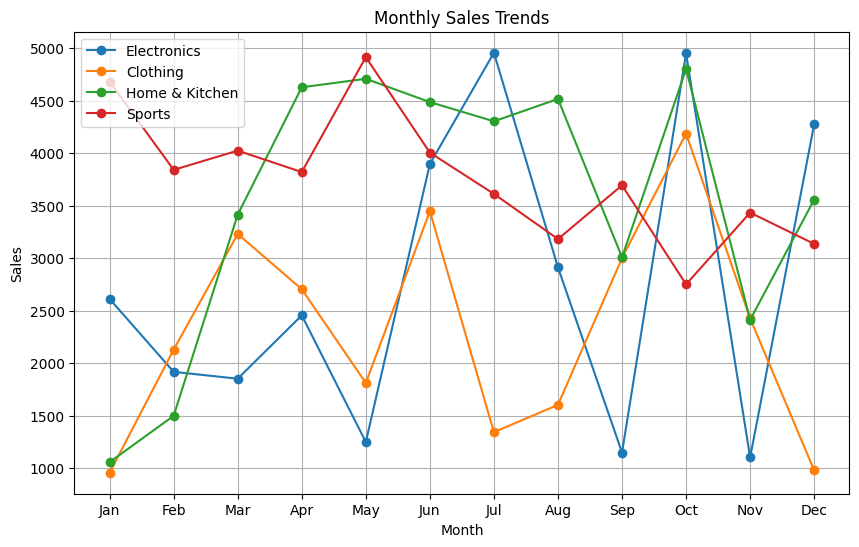

In [15]:
import matplotlib.pyplot as plt

# 1. Monthly Sales Trends (Line Plot)

plt.figure(figsize=(10,6))

for column in columns:
    plt.plot(df.index, df[column], marker='o', label=column)

plt.title("Monthly Sales Trends")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()


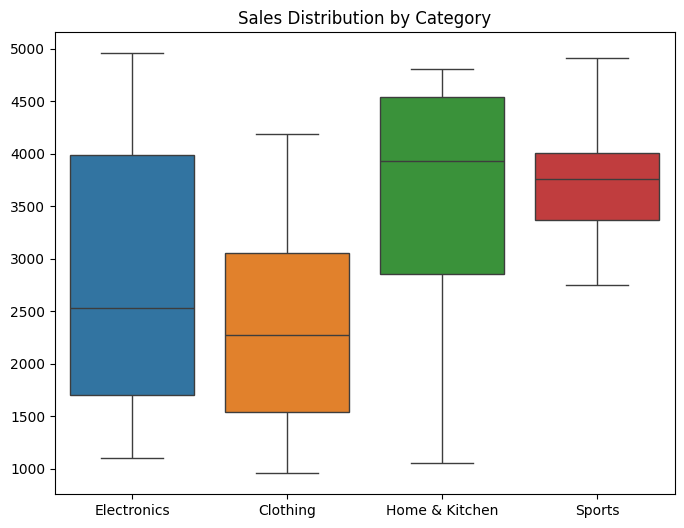

In [17]:
# 2. Box Plot – Sales Distribution
import seaborn as sns
plt.figure(figsize=(8,6))
sns.boxplot(data=df[columns])
plt.title("Sales Distribution by Category")
plt.show()

In [ ]:
# Q.2 For the array: array = np.array([[1, -2, 3],[-4, 5, -6]])

In [18]:
# i) Element-wise Absolute Value

array = np.array([[1, -2, 3],[-4, 5, -6]])
np.abs(array)

array([[1, 2, 3],
       [4, 5, 6]])

In [19]:
# ii) Percentiles

# Flattened
np.percentile(array.flatten(), [25, 50, 75])

# Column-wise
np.percentile(array, [25, 50, 75], axis=0)

# Row-wise
np.percentile(array, [25, 50, 75], axis=1)

array([[-0.5, -5. ],
       [ 1. , -4. ],
       [ 2. ,  0.5]])

In [20]:
# iii) Mean, Median, Std

# Flattened
print("Mean:", np.mean(array))
print("Median:", np.median(array))
print("Std:", np.std(array))

# Column-wise
print("Column Mean:", np.mean(array, axis=0))
print("Column Median:", np.median(array, axis=0))
print("Column Std:", np.std(array, axis=0))

# Row-wise
print("Row Mean:", np.mean(array, axis=1))
print("Row Median:", np.median(array, axis=1))
print("Row Std:", np.std(array, axis=1))

Mean: -0.5
Median: -0.5
Std: 3.8622100754188224
Column Mean: [-1.5  1.5 -1.5]
Column Median: [-1.5  1.5 -1.5]
Column Std: [2.5 3.5 4.5]
Row Mean: [ 0.66666667 -1.66666667]
Row Median: [ 1. -4.]
Row Std: [2.05480467 4.78423336]


In [21]:
# Q.3 For the array: a = np.array([-1.8, -1.6, -0.5, 0.5,1.6, 1.8, 3.0]).

a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

print("Floor:", np.floor(a))
print("Ceiling:", np.ceil(a))
print("Truncated:", np.trunc(a))
print("Rounded:", np.round(a))

Floor: [-2. -2. -1.  0.  1.  1.  3.]
Ceiling: [-1. -1. -0.  1.  2.  2.  3.]
Truncated: [-1. -1. -0.  0.  1.  1.  3.]
Rounded: [-2. -2. -0.  0.  2.  2.  3.]


In [22]:
# Q.4 WAP to swap two elements in a list in Python Using a Temporary Variable.

lst = [10, 20, 30, 40]

pos1 = 1
pos2 = 3

temp = lst[pos1]
lst[pos1] = lst[pos2]
lst[pos2] = temp

print("Swapped List:", lst)

Swapped List: [10, 40, 30, 20]


In [23]:
# Q.5 Write a Python program to swap two elements in a set by converting it to a list first.

s = {1, 2, 3, 4}

# Convert to list
lst = list(s)

pos1 = 0
pos2 = 2

# Swap
lst[pos1], lst[pos2] = lst[pos2], lst[pos1]

# Convert back to set
s = set(lst)

print("Swapped Set:", s)

Swapped Set: {1, 2, 3, 4}
